In [3]:
#Author: Thomas Cooper
#Building a flat siumulation for the south arm that fluctuates between 4190 and 4193

#packages
import os 
import pandas as pd                                 ## dataframe framework
import numpy as np                                  ## provides library of basic mathematical functions
import matplotlib.pyplot as plt                     ## necessary for plotting

In [14]:
df = pd.read_excel("na_optimistic_sim.xlsx")
df = df.drop(columns=['vol','area','stage-ft_NGVD29'])
df = df.rename(columns = {'stage_m_NVD88' : 'na_m_NVD88'})
df.head()


,Column1,days,dates,na_m_NVD88
0,0,0,2026-09-01,1278.178800
1,1,1,2026-09-02,1278.167920
2,2,2,2026-09-03,1278.160089
3,3,3,2026-09-04,1278.158356
4,4,4,2026-09-05,1278.145799


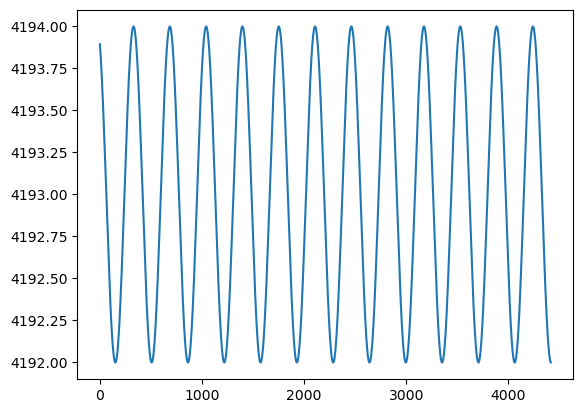

In [192]:
t = df['days']

#params
slope = 0      # Rate of linear decrease (m)
intercept = 4193   # Starting y-value (c)
amplitude = 1   # Height of the sine wave (A)
frequency =  (6.45/365)   # Cycles per unit of x (omega)
phase = 90     # Horizontal shift (phi)

def elevation(t):
    return (slope*t + intercept) + (amplitude*np.sin(frequency*t + phase))


plt.plot(t,elevation(t))
#looks good to me

In [193]:
df['sa_elev_sim'] = elevation(df['days'])
df['na_elev_sim'] = df['na_m_NVD88']*3.281

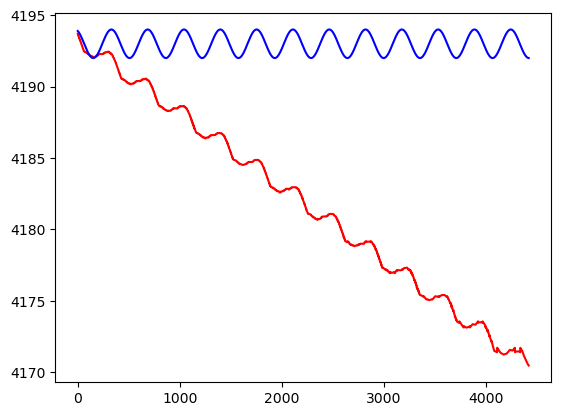

In [196]:
#Plotting both elevations
plt.plot(df['days'],df['na_elev_sim'],color="red")
plt.plot(df['days'],df['sa_elev_sim'],color="blue")
plt.show()
#Looks good to me

In [198]:
#year columns
df['year'] = df['dates'].dt.year
df.head()

df.to_excel("sim_for_animation.xlsx")